# FNO3d Predictions

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from model_3d import FNO3d, add_grid
from train_utils import load_data_3D

In [ ]:
# Paths and training params
DATA_PATH  = "data/ns_V1e-3_N5000_T50.mat"
MODEL_PATH = "outputs/fno3d_final.pt" # "outputs/fno3d_latest.pt"

n_train = 200
n_test = 50
T_in = 10
T = 40
S = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Again definining this loss to compute it per sample.

In [10]:
def relative_l2(pred, target):
    B = pred.shape[0]
    diff = torch.norm(pred.reshape(B, -1) - target.reshape(B, -1), dim=1)
    tgt = torch.norm(target.reshape(B, -1), dim=1)
    return diff / tgt

In [31]:
# Load data
a_train, u_train, a_test, u_test = load_data_3D(DATA_PATH, n_train, n_test, T_in, T, S)

x_test = add_grid(a_test)

model = FNO3d(n_modes_x=8, n_modes_y=8, n_modes_t=8, width=20, T_in=T_in).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

with torch.no_grad():
    pred_all = model(x_test.to(device)).squeeze(1).cpu()

errs = relative_l2(pred_all, u_test)

### Plotting predictions

C:\Users\Galek\AppData\Local\Temp\ipykernel_28792\1632671548.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


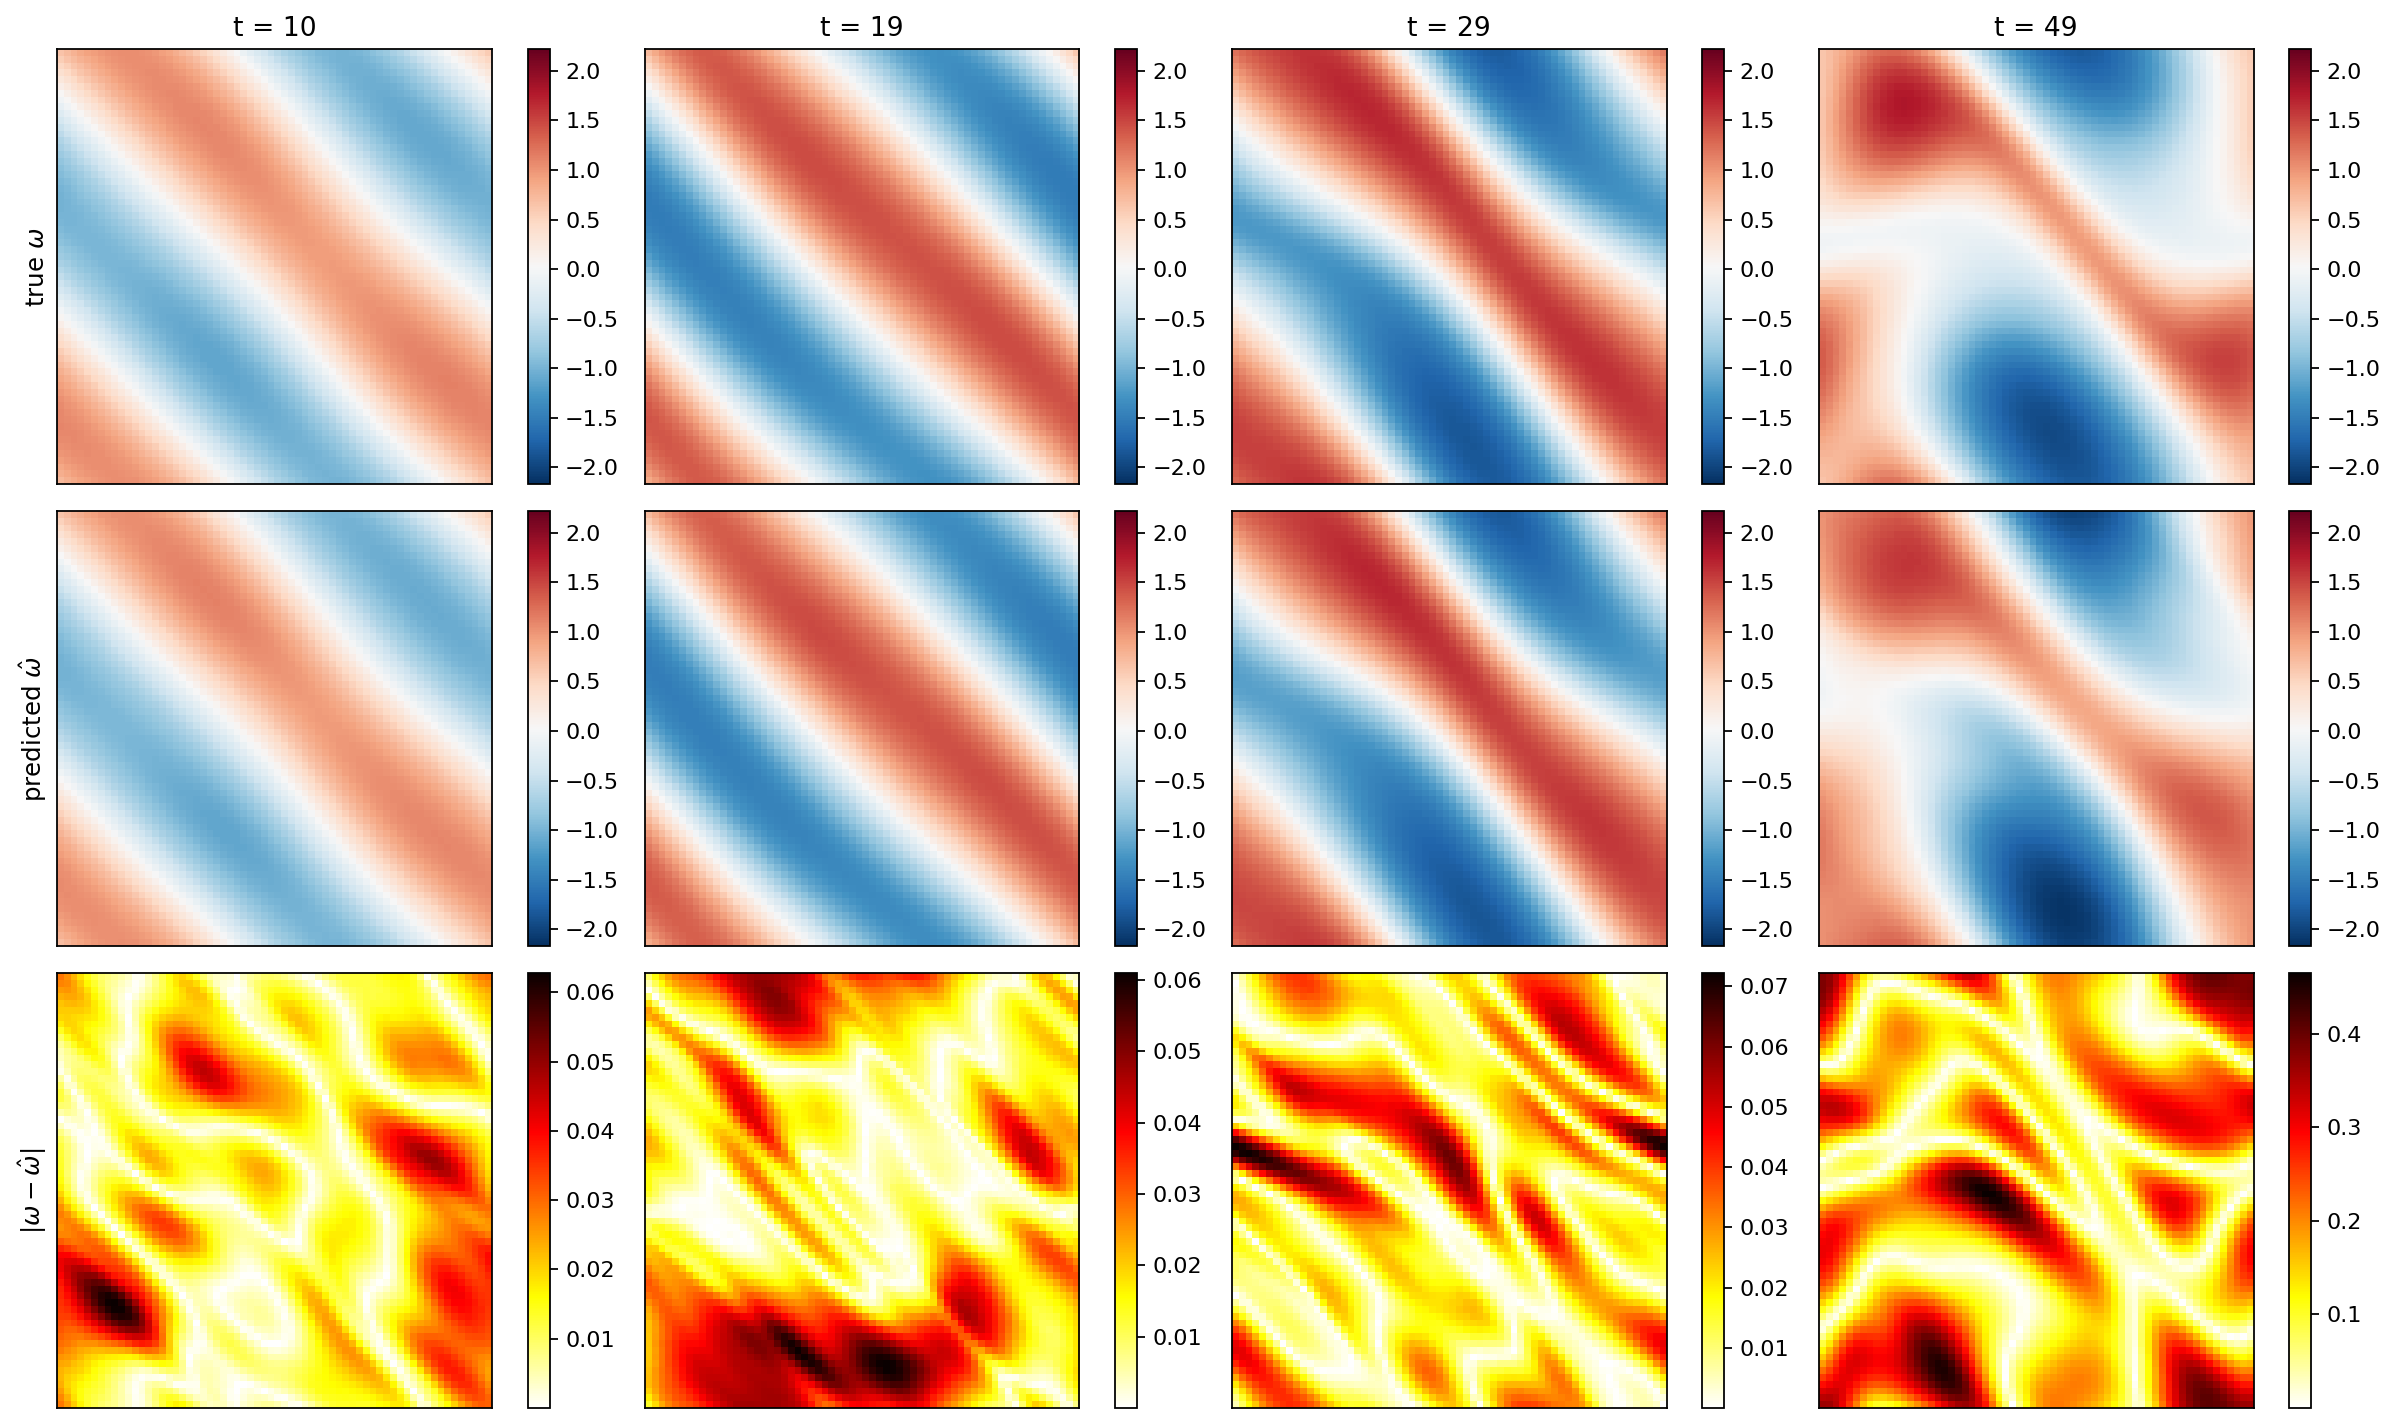

In [32]:
sample_idx = 0
t_steps = [0, 9, 19, 39]
# t_steps = [0, 19, 35] 

u = u_test[sample_idx]
pred = pred_all[sample_idx]

fig, axes = subplots(3, len(t_steps), figsize=(16, 9), dpi=160)
# fig.suptitle(f"Sample {sample_idx}", fontsize=13, y=1.02)

vmin = min(u.min().item(), pred.min().item())
vmax = max(u.max().item(), pred.max().item())

for col, t in enumerate(t_steps):
    err = (u[:, :, t] - pred[:, :, t]).abs()

    im0 = axes[0, col].imshow(u[:, :, t], origin="lower", vmin=vmin, vmax=vmax, cmap="RdBu_r")
    axes[0, col].set_title(f"t = {T_in + t}")
    im1 = axes[1, col].imshow(pred[:, :, t], origin="lower", vmin=vmin, vmax=vmax, cmap="RdBu_r")
    im2 = axes[2, col].imshow(err, origin="lower", cmap="hot_r")

    plt.colorbar(im1, ax=axes[1, col], fraction=0.045)
    plt.colorbar(im0, ax=axes[0, col], fraction=0.045)
    plt.colorbar(im2, ax=axes[2, col], fraction=0.045)

    for row in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

axes[0, 0].set_ylabel("true $\\omega$", fontsize=11)
axes[1, 0].set_ylabel("predicted $\\hat{\\omega}$", fontsize=11)
axes[2, 0].set_ylabel("$|\\omega - \\hat{\\omega}|$", fontsize=11)

fig.subplots_adjust(wspace=-.2)
fig.tight_layout()
fig.show()

### Error over time

C:\Users\Galek\AppData\Local\Temp\ipykernel_28792\4030869114.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


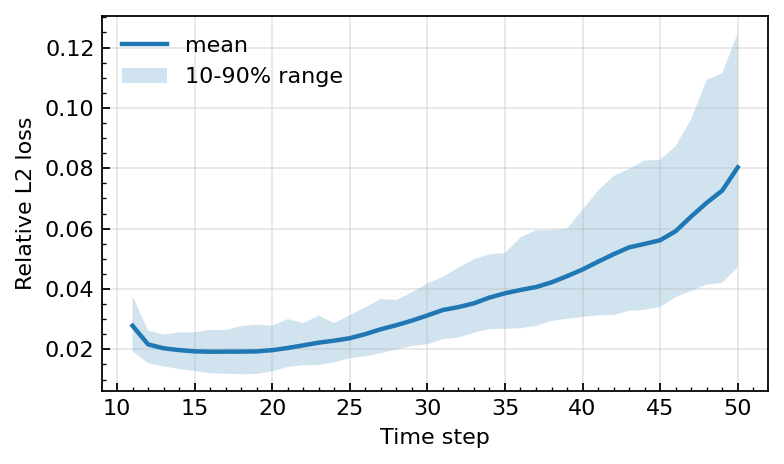

In [36]:
err_per_t = []
q10_per_t = []
q90_per_t = []

for t in range(T):
    # Batch size
    B = pred_all.shape[0]

    # Norm of per pixel differences and magnitudes
    diff = torch.norm((pred_all[:, :, :, t] - u_test[:, :, :, t]).reshape(B, -1), dim=1)
    tgt = torch.norm(u_test[:, :, :, t].reshape(B, -1), dim=1)
    rel = (diff / tgt).numpy()

    err_per_t.append(rel.mean())
    q10_per_t.append(np.quantile(rel, 0.1))
    q90_per_t.append(np.quantile(rel, 0.9))

times = range(T_in+1, T_in+1+T)

fig, ax = subplots(figsize=(5, 3), dpi=160)

ax.plot(times, err_per_t, lw=2, label="mean")
ax.fill_between(times, q10_per_t, q90_per_t, alpha=0.2, label="10-90% range")

ax.set_xlabel("Time step")
ax.set_ylabel("Relative L2 loss")
ax.minorticks_on()
ax.grid(True, alpha=0.3)
ax.tick_params(direction="in", which="both")
ax.legend(frameon=False)

fig.tight_layout()
fig.show()
